# ISIS `photomet` (Hapke) hillshading vs. the plain Lambertian fallback

`image_generation.ipynb`'s hillshade-based ortho basemap (`dem_ortho_result.ortho`, Phase 3) is
shaded with a real Hapke bidirectional reflectance function by default (ISIS `photomet`,
`PHTNAME=HAPKEHEN`, `lunaserv.hapke_shade_ortho` -- see `docs/history.md`'s dated entries for the
evaluation that led here). `lunaserv.fetch_dem_and_ortho`/`despeckle_and_shade_ortho`'s `hapke`
parameter (`lunaserv.DEFAULT_HAPKE_SHADING`) still keeps the original plain Lambertian
`matplotlib.colors.LightSource.hillshade` blend (`lunaserv.shade_ortho`) available as a fallback
(`hapke=False`) -- real-sun-direction-lit, but not a real photometric model (no opposition surge,
no macroscopic-roughness term, no real lunar reflectance behavior). This notebook is a reference/
regression comparison between the two -- not an "should we do this" evaluation anymore -- showing
what the Hapke default actually changes relative to that fallback for a real image.

The tricky part evaluated here: `photomet`'s automatic angle sources (`ANGLESOURCE=ELLIPSOID`/
`DEM`) need a real ISIS camera model embedded in the cube (via `spiceinit`) to derive
incidence/emission/phase angles from -- but this ortho is a flat, map-projected mosaic with no
ISIS camera model at all (real or synthetic). The fix used here: `ANGLESOURCE=BACKPLANE`, feeding
`photomet` angle rasters computed directly in Python (`lunaserv._terrain_photometric_angles`) --
`photomet` only does the Hapke math, not the geometry. This sidesteps the "no camera model"
problem entirely.

Those angle rasters use the synthetic camera's own **real, finite position**
(`Camera.camera_center_moon_me_m`, used directly in real MOON_ME coordinates -- see
`lunaserv._terrain_photometric_angles`'s own docstring), not an idealized
infinitely-distant nadir viewer -- so emission and phase genuinely vary per pixel from actual
parallax (each pixel's own real vector to the spacecraft), the same real perspective geometry
`sat_sim`'s own synthetic render is posed with, not just local terrain slope. An earlier version
of this notebook used a nadir approximation (emission from local-normal-vs-straight-up only,
scene-wide phase) -- see docs/history.md's dated entry for why that was replaced: it couldn't
capture any real emission-angle-dependent brightening across the frame, which is exactly the kind
of effect a real Hapke BRDF (vs. Lambertian) is supposed to add.

Minimum setup to get there: reuses `image_generation.ipynb`'s Phase 1-2 exactly (same manifest,
same `TrnTestDataSet`), but skips `dataset.populate()` entirely -- `entry.camera` is enough to
fetch a DEM/ortho pair, and this notebook doesn't need the `sat_sim` render or the ISIS WAC crop
either phase would otherwise generate. Displays the existing Lambertian ortho blinked against a
freshly-fetched Hapke-shaded ortho of the same footprint, via the same `plot_overlay_toggle`
blink-comparator Phase 5B/6B use -- here comparing the two shading modes directly against each
other (both share the exact same pixel grid, being the same DEM/ortho fetch with only the final
shading step differing) rather than comparing a render against a basemap.

In [1]:
import trntest
from trntest import lunaserv, plotting

images = trntest.read_manifest("dataset_manifest.csv")
session = trntest.Session()

dataset = trntest.TrnTestDataSet.create(session.config.output_dir / "trn_dataset", images, session.config)
entry = dataset[0]
camera = entry.camera

print(f"EDR product: {entry.edr_product}")
print(f"Ground footprint center (lon, lat): {camera.footprint_lonlat_deg['center']}")

EDR product: M1327210646CE
Ground footprint center (lon, lat): (np.float64(169.57486295444002), np.float64(38.762076138016))


## Fetch both shading variants

`entry.dem_ortho_result` is the current *default* basemap -- Hapke-shaded (resumed from disk if
`image_generation.ipynb` already generated it for this manifest entry, else fetched fresh here;
see `TrnTestEntry.dem_ortho_result`'s own docstring for how it stays mode-aware about which
cached file to resume from). `lunaserv.fetch_dem_and_ortho(..., hapke=False)` fetches the same
DEM/ortho pair again -- cheap, Lunaserv/Astropedia fetches are independently cached by `cache.py`
-- but shades it with the plain Lambertian fallback instead, writing to its own `ortho_shaded.tif`
so it doesn't collide with the Hapke file.

In [2]:
dem_ortho_hapke = entry.dem_ortho_result
dem_ortho_lambertian = lunaserv.fetch_dem_and_ortho(camera, entry.per_image_config, hapke=False)

print("Hapke ortho:      ", dem_ortho_hapke.ortho)
print("Lambertian ortho: ", dem_ortho_lambertian.ortho)

ROI center (lon,lat deg): (np.float64(169.57486295444002), np.float64(38.762076138016)), bbox (local m): (-108890.25715708971, -111272.07330603541, 116875.28589842163, 115462.19114175175)
ROI size 2258x2267 px (~100.0 m/px)


Hapke ortho:       /workspace/output/trn_dataset/_work/M1327210646CE/ortho_shaded_hapke_atc_realparams_normaltilt.tif
Lambertian ortho:  /workspace/output/trn_dataset/_work/M1327210646CE/ortho_shaded.tif


## Blink comparison

Both orthos share the exact same real georeferencing/pixel grid (same camera footprint, same DEM,
only the final shading step differs), so this is a direct visual read of what the Hapke default
changes relative to the plain Lambertian fallback -- real emission-angle-dependent brightening
toward the side of the frame the camera is looking more obliquely at (a genuine parallax effect
the Lambertian path has no equivalent of at all, since it only ever considers the Sun, never the
viewer), opposition-surge brightening near the sub-solar point, a different incidence-angle
falloff, etc. -- not a geo-registration check like Phase 5B/6B's own use of this same
blink-comparator.


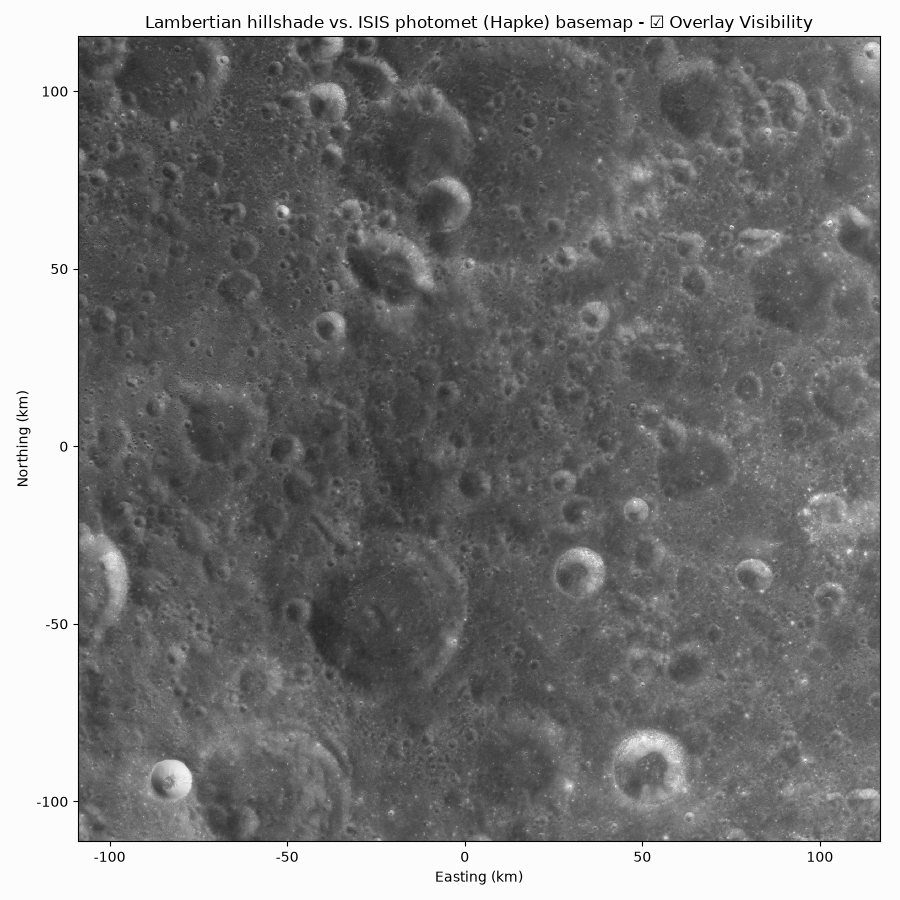

In [3]:
plotting.plot_overlay_toggle(
    dem_ortho_lambertian.ortho,
    dem_ortho_hapke.ortho,
    title="Lambertian hillshade vs. ISIS photomet (Hapke) basemap",
)